<a href="https://colab.research.google.com/github/readytocommit/FinalProject/blob/main/TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [193]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [194]:
#When we train Deep Leatning models, randomness enters the process in few different places,

"""
Starting values for the weights (the optimizer will try to improve these weights)
The order in which we process minibatches when we do SGD
When we split the data into Train, Validation,Test etc
Droupout if we use regularization

We set seed for the different random number generators so that the results will be same every time the notebook is run.


"""


'\nStarting values for the weights (the optimizer will try to improve these weights)\nThe order in which we process minibatches when we do SGD\nWhen we split the data into Train, Validation,Test etc\nDroupout if we use regularization\n\nWe set seed for the different random number generators so that the results will be same every time the notebook is run.\n\n\n'

In [195]:
keras.utils.set_random_seed(42)

#Reading the data
file_url = file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
df = pd.read_csv(file_url)


In [196]:

print(df.shape)
df.head()



(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [197]:
# Lets take a look if 1s and 0s are balaced or not.

df.target.value_counts(normalize=True,dropna= False)

,proportion
target,
0,0.726073
1,0.273927


In [198]:
# From the data we can see that 72 % dont have the heart dieases
# and only 27 % people have the heart disease.

# It is a bit imbalanced

# "Whats a naive baseline model for this problem ? "

# A baseline model would just predict a proabillity of 0.0 for every patient. That will result in 72.6% accuracy.
# Any fancy model we build needs to do better than this

In [199]:
#Preprocessing

# This dataset has both categorical variables and numeric variables.

# It will be convinient (for later processing) to collect these groups of variables into two lists

df.to_csv("data.csv")

print(df.head(n = 5))
print(df.shape)
print(df.columns)

#From the table we can see that

numerical_variables = ['age','trestbps','chol','thalach','oldpeak','slope']
categorical_variables = ['sex','cp','fbs','restecg','exang','ca','thal']



#NNs require all their inputs to be numeric so we will first preprocess this raw data as follows:

# one-hot encode the categorical variables
# normalize the numeric variables

# with the pandas get_dummies function, you can one-hot-encode in one line.

df = pd.get_dummies(df,columns= categorical_variables)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)



   age  sex  cp  trestbps  chol  ...  oldpeak  slope  ca        thal  target
0   63    1   1       145   233  ...      2.3      3   0       fixed       0
1   67    1   4       160   286  ...      1.5      2   3      normal       1
2   67    1   4       120   229  ...      2.6      2   2  reversible       0
3   37    1   3       130   250  ...      3.5      3   0      normal       0
4   41    0   2       130   204  ...      1.4      1   0      normal       0

[5 rows x 14 columns]
(303, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [200]:
df.head()


,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,cp_4,fbs_0,fbs_1,restecg_0,restecg_1,restecg_2,exang_0,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,1,0,0
1,67,160,286,108,1.5,2,1,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0
2,67,120,229,129,2.6,2,0,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1
3,37,130,250,187,3.5,3,0,0,1,0,0,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0
4,41,130,204,172,1.4,1,0,1,0,0,0,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0,1,0


In [201]:
#NNs work best when the inputs are all roughly in the same range. So standard practice is to standardize the numeric variables.
#Before we do so, let's split the data into an 80% training set and 20 % test set (why should we split before normalization ?)

# Because otherwise the test set will be influenced by the trainig set if we  do it earlier.

test_df = df.sample(frac= 0.2, random_state=42)
train_df = df.drop(test_df.index)

In [202]:
print(test_df.shape)
print(train_df.shape)

(61, 30)
(242, 30)


In [203]:
# let's calculate the mean and standard deviation of every numeric variable in the training set.

means = test_df[numerical_variables].mean()
sd = train_df[numerical_variables].std()

means

,0
age,55.885246
trestbps,130.950820
chol,246.688525
thalach,146.770492
oldpeak,1.157377
slope,1.590164


In [204]:
sd

,0
age,9.059861
trestbps,18.012789
chol,48.485377
thalach,23.132298
oldpeak,1.169729
slope,0.632783


In [205]:
# Let's standardalize the train and test dataframes with these means and the standard deviations

train_df[numerical_variables] = (train_df[numerical_variables]-means) / sd

test_df[numerical_variables] = (test_df[numerical_variables]-means) / sd

In [206]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,cp_4,fbs_0,fbs_1,restecg_0,restecg_1,restecg_2,exang_0,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.785305,0.779956,-0.282323,0.139610,0.976827,2.227991,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,1,0,0
1,1.226813,1.612698,0.810790,-1.676033,0.292908,0.647672,1,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0
2,1.226813,-0.607947,-0.364822,-0.768211,1.233297,0.647672,0,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1
3,-2.084496,-0.052786,0.068298,1.739106,2.002706,2.227991,0,0,1,0,0,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0
4,-1.642988,-0.052786,-0.880441,1.090662,0.207418,-0.932647,0,1,0,0,0,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0,1,0


In [207]:
test_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,cp_4,fbs_0,fbs_1,restecg_0,restecg_1,restecg_2,exang_0,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
179,-0.759973,-0.718979,-2.014804,-0.897900,-0.305521,-0.932647,0,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0
228,-0.097711,-0.163818,-0.859816,-0.724982,0.720357,0.647672,1,1,0,0,0,0,0,1,1,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1
111,-0.208088,-1.163108,-0.674193,0.485447,0.378398,0.647672,0,1,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0
246,0.123043,-0.052786,-0.220448,1.177121,-0.989440,0.647672,0,1,0,0,0,1,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0
60,1.116436,-0.607947,1.140787,0.182840,-0.647481,0.647672,0,0,1,0,0,0,0,1,1,0,0,0,1,1,0,1,0,0,0,0,0,0,1,0


In [208]:
#At this point, the data is entirely numeric.
# The easies way to feed data to Keras/Tensorflow is as Numpy arrays so we convert our two dataframes to Numpy arrays.

train = train_df.to_numpy()
test = test_df.to_numpy()



In [209]:
train


array([[ 0.78530498,  0.77995586, -0.28232274, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.22681285,  1.61269754,  0.81079034, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.22681285, -0.60794693, -0.36482184, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-1.42223437,  0.05824641,  1.94515297, ...,  0.        ,
         0.        ,  1.        ],
       [-0.87034953, -0.05278581,  0.19204709, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.78530498,  1.05753642,  3.30638813, ...,  0.        ,
         0.        ,  1.        ]])

In [210]:
test

array([[-0.75997256, -0.71897915, -2.01480385, ...,  0.        ,
         1.        ,  0.        ],
       [-0.09771076, -0.16381803, -0.85981644, ...,  0.        ,
         0.        ,  1.        ],
       [-0.20808773, -1.16310804, -0.67419347, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.00605892,  0.22479475,  0.15079754, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.23342014, -1.71826916, -0.26169797, ...,  0.        ,
         0.        ,  1.        ],
       [-1.09110346, -0.60794693,  0.04767366, ...,  0.        ,
         0.        ,  1.        ]])

In [211]:
#Final step: Our features X and dependent variable Y are both inside the train and test arrays so lets seperate them out.

# Note that the target column is our y variable and it is column # 6 (counting from 0)
# The np.delete dunction is perfect for selecting all columns except one

train_X = np.delete(train,6,axis=1)
test_X = np.delete(test,6,axis=1)


#Check that it worked

train_X.shape, test_X.shape

((242, 29), (61, 29))

In [212]:
# Next, select just the 6th column and define the train and test y variables.

train_y = train[:,6]
test_y = test[:,6]

train_y.shape, test_y.shape

print(train_y)

[0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1.
 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1.
 1. 1.]


In [213]:
#Build a model

# Creating an NN is usually just a few lines of keras codes .
# We will start with single hidden layer.
# Since this is binary classification problem , we will use a sigmoid activation in the output layer.

# Building a model

num_columns = train_X.shape[1]

#define the input layer
input = keras.Input(shape = (num_columns,))

#feed the input vector to the hidden layer
# optional: you can give names to each layer to hwlp
# keep track. This doesn't affect the training etc.

h = keras.layers.Dense(16,activation="relu",name="Hidden")(input)

#feed the output of the hidden layer to the output layer

output = keras.layers.Dense(1,activation="sigmoid", name="Output")(h)

#tell the keras that this (input,output) pair is your model
model = keras.Model(input,output)


In [214]:
#The model.summary() command is a good way to get a quick overview of what have you defined

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [215]:
# Parameter calculation  # 16 and 1 bias

(29+1)*16 + (16+1) * 1

497

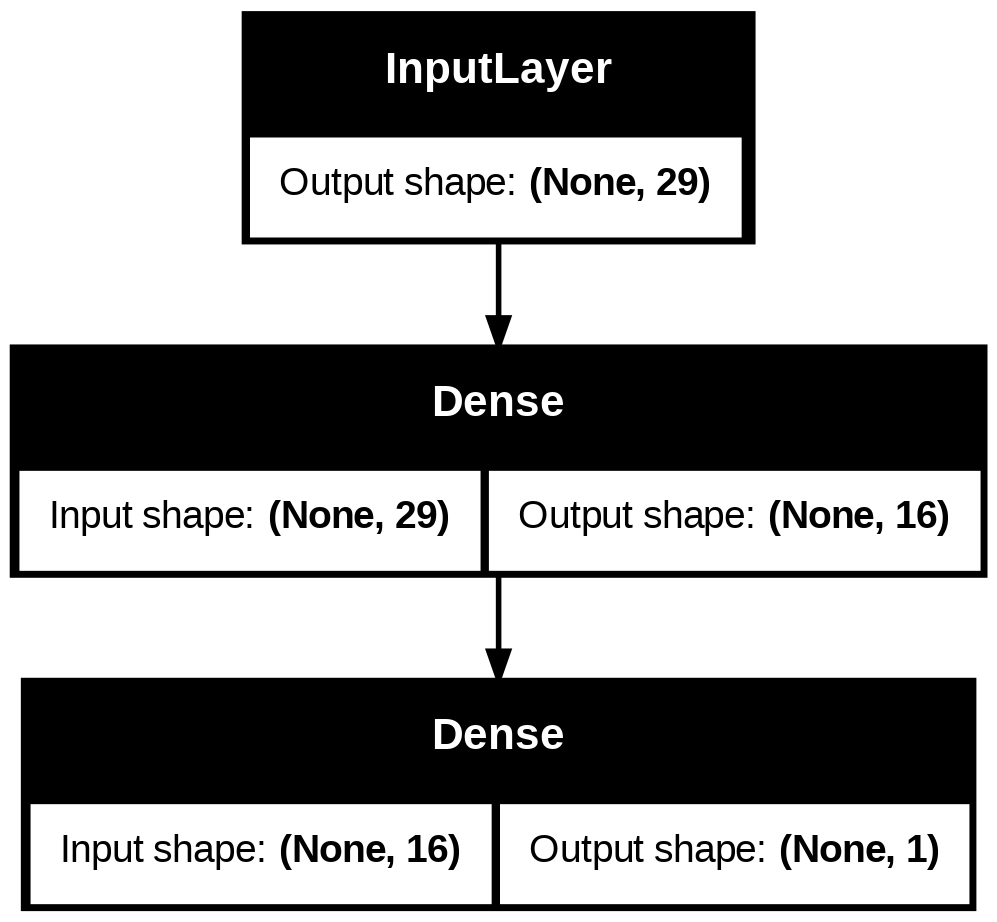

In [216]:
#We can visualize the network graphically as well using Keras plot_model function

keras.utils.plot_model(model, show_shapes= True)

In [217]:
#Set optimize parameters

# Now that the model is defined, we need to tell Keras three things.

# What loss function to use- Since our output variable is a binary, we will select the binary_crossentropy function.
# which optimizer to use- we will use a sibling of SGD called Adam which is an excellent default choice.
# What metrices you want Keras to report out- in classification problems like this one, Accuracy is usually the metric you want to see.

# three choices can be made using the model.compile function.

model.compile(
    optimizer  = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)



In [218]:
#Train the model

# The kickoff training, we have decided on three things:

# The batch size: We referred to this as a minibatch in lecture but in keeping with convention, we will simply refer to it as batch from this point on.
# 32 is a good default size for the batch size.

# The number of epochs i.e. how many passes through the training data. Usally 20-30 epochs is good starting point but since this dataset is very small, each epoch will be very quick so
# let's run it for 300 epochs. It will allow us to see if any overfitting happens.

# Whatever we want to use a validation tes. This will be useful for overfitting detection and regularization via early stopping so we will ask Keras to automatically use 20%
 # of the data points as a validation set


 # Ok let's train the model using the model.fit function

In [219]:
# We will store the output of the training process in history. It will make it easy later to investigate what happened during training.

history = model.fit(
    train_X,    #the array with the input X columns
    train_y,  #the array with the output y column
    epochs = 300,  #The number of epochs to run
    batch_size = 32,  #the number of samples (i.e data points) per batch
    verbose = 1, # verbosity during training   # Progress bar
    validation_split = 0.2)  #use 20% of data for validation   (i want to use overfitting using this 20 % . so dont use it)


Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.5596 - loss: 0.7100 - val_accuracy: 0.5714 - val_loss: 0.6844
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6114 - loss: 0.6782 - val_accuracy: 0.6122 - val_loss: 0.6656
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6425 - loss: 0.6548 - val_accuracy: 0.6122 - val_loss: 0.6483
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6580 - loss: 0.6331 - val_accuracy: 0.6327 - val_loss: 0.6319
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7150 - loss: 0.6130 - val_accuracy: 0.6122 - val_loss: 0.6171
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7306 - loss: 0.5945 - val_accuracy: 0.6531 - val_loss: 0.6032
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7306 - loss: 0.5773 - val_accuracy: 0.6735 - val_loss: 0.5900
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7565 - loss: 0.5609 - val_accuracy: 0.7143 - val_loss

In [220]:
#Meaning: In this 300 epoch it used 7/7 batches   val_accuracy -> validation accuracy

#Plotting metrics like loss and accuracy as  a function of the # of epoch is a good way to understand how training has progressed.

history_dict = history.history
history_dict.keys()



dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

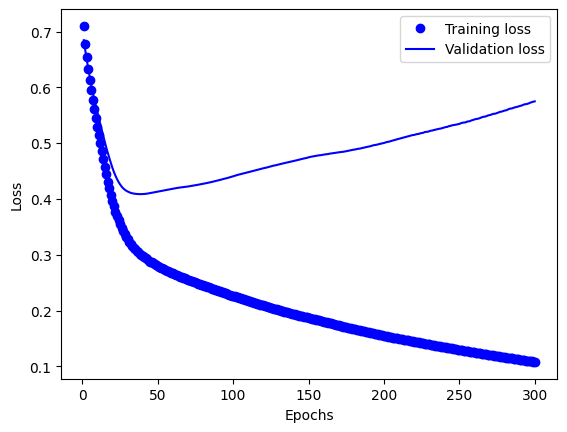

In [221]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

epochs = range(1,len(loss_values)+1)
plt.plot(epochs, loss_values,"bo",label="Training loss")
plt.plot(epochs,val_loss_values,"b",label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

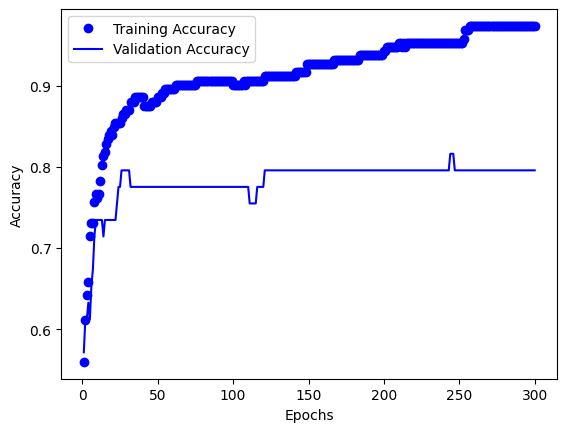

In [224]:
train_accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]

epochs = range(1,len(loss_values)+1)
plt.plot(epochs, train_accuracy,"bo",label="Training Accuracy")
plt.plot(epochs,val_accuracy,"b",label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [225]:
# Does this have overfitting

# Yes it does have but the model goes better at the end. So we can live with it ..